# 04 — Analyse : grille budget-annotation (3 paradigmes)

Spine analytique de la grille. On charge **les trois paradigmes** sur des
splits/seeds/test-sets **identiques** (`make_balanced_splits`, GRID-01/02), on franchit
les **portes d'intégrité** (ANA-02 complétude, ANA-03 alignement par (système, seed)), puis
on **recalcule toute métrique via `helpers`** (ANA-04) dans une seule trame longue `unified`
(>= 14 system-runs). Aucun chiffre rapporté n'est lu depuis `metrics_*.csv` — chaque valeur
trace vers un appel `helpers`. Les 6 systèmes encodeur portent hF1-AUC ; les 8 systèmes LLM
ne le portent **jamais** (absence structurée : étiquette sans distribution, ANA-04).



In [1]:
import os, sys
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")

import helpers as h
DEVICE = h.get_device()
os.makedirs("artifacts", exist_ok=True)

[device] using 'mps' (cuda=False, mps=True) | torch 2.11.0


## Chargement des trois paradigmes

In [2]:
# Source unique des splits/test-sets (GRID-01/02) : le MEME chargement que 01_flat/03_llm.
# Ne PAS re-deriver les leaf_labels a la main.
import json

df, _ = h.load_m9()
tax = h.Taxonomy.from_leaves(df["leaf_label"].unique())
# leaf_order encodeur = ordre des colonnes des probs_*.npz = sorted(tax.terminals)
# (== clf.classes_ ; 01_flat cell 8 / 02_setfit). NE PAS inventer un ordre.
LEAF_ORDER = sorted(tax.terminals)
assert len(LEAF_ORDER) == 13, f"attendu 13 feuilles, vu {len(LEAF_ORDER)}"

llm = pd.read_csv("artifacts/llm_flat_results.csv")
print("df:", df.shape, "| n_leaves:", len(LEAF_ORDER), "| llm:", llm.shape)
print("llm models:", sorted(llm["model"].unique()), "| conditions:", sorted(llm["condition"].unique()))


df: (234, 8) | n_leaves: 13 | llm: (5200, 13)
llm models: ['gemma4:26b', 'gemma4:e4b'] | conditions: ['0a', '0b', '3', '8']


## ANA-02 — Porte de complétude (STOP)

Portée verbatim de `03_llm.ipynb` cell 19 : 5 200 clés uniques `(seed,model,condition,example_id)`,
**zéro** `done_reason=='length'`, **zéro** `snap_reason` commençant par `exception_`. Le taux de
`global_fallback` par (modèle, condition) est **calculé et conservé** (pour le reporting ANA-08 en
Plan 03), **pas** asserté à zéro. Le `num_ctx` par condition est **lu** depuis le sidecar
`.meta.json` (R8=32768, jamais le 16384 hérité).

In [3]:
# ANA-02 completeness gate (porte verbatim de 03_llm cell 19) — STOP sur donnees incompletes/abimees.
n_unique = len(set(zip(llm["seed"], llm["model"], llm["condition"], llm["example_id"])))
assert n_unique == 5200, f"INCOMPLET: {n_unique} != 5200 cles uniques — STOP"
# Domaine des cles epingle : une ligne parasite (modele/condition inattendu) ne peut pas
# compenser une cle legitime manquante dans le total de 5200. Reutilises par ANA-04.
LLM_MODELS = ["gemma4:26b", "gemma4:e4b"]
LLM_CONDS = ["0a", "0b", "3", "8"]
assert set(llm["model"]) == set(LLM_MODELS), \
    f"modeles inattendus: {sorted(set(llm['model']))} — STOP"
assert set(llm["condition"]) == set(LLM_CONDS), \
    f"conditions inattendues: {sorted(set(llm['condition']))} — STOP"
assert (llm["done_reason"].astype(str) == "length").sum() == 0, \
    "troncature non investiguee (done_reason=='length') — STOP"
assert llm["snap_reason"].astype(str).str.startswith("exception_").sum() == 0, \
    "exceptions presentes (snap_reason exception_*) — STOP"

# global_fallback : CALCULE et conserve (ANA-08 le rapporte en Plan 03), PAS asserte a zero.
global_fallback = (
    llm.assign(fb=llm["snap_reason"].astype(str).eq("global_fallback"))
       .groupby(["model", "condition"])["fb"].mean()
)

# num_ctx par condition : LU depuis le sidecar (R8=32768), jamais code en dur a 16384.
with open("artifacts/llm_flat_results.csv.meta.json") as fh:
    llm_meta = json.load(fh)
num_ctx_by_condition = llm_meta["options"]["num_ctx_by_condition"]

print(f"complet: {n_unique} cles uniques (== 5200)")
print("done_reason=='length': 0 | exception_*: 0 (portes franchies)")
print(f"global_fallback max par (modele,condition): {global_fallback.max():.4f} (>0.02 a signaler en ANA-08)")
print(f"num_ctx_by_condition (sidecar): {num_ctx_by_condition}")


complet: 5200 cles uniques (== 5200)
done_reason=='length': 0 | exception_*: 0 (portes franchies)
global_fallback max par (modele,condition): 0.0000 (>0.02 a signaler en ANA-08)
num_ctx_by_condition (sidecar): {'0a': 16384, '0b': 16384, '3': 16384, '8': 32768}


## Cohérence inter-colonnes (encoder + max_length)

Garde de provenance `assert_coherent` sur `keys=("encoder", "max_length")` à travers **les six
sidecars de colonnes encodeur** consommés par la boucle ANA-04 (`ENC_SYSTEMS`, sidecar de
référence `metrics_setfit_8`). `git_commit` est **intentionnellement exclu** : la grille a régénéré
les colonnes en vagues/commits séparés par construction (décision Phase 12 Plan 04).

In [4]:
# Cohérence inter-colonnes sur (encoder, max_length) — PAS git_commit (vagues séparées).
# Les SIX sidecars encodeur consommés par la boucle ANA-04 sont gardés (pas seulement 2) :
# une régénération 256-view périmée de n'importe quelle colonne (mode d'échec CR-01) STOPpe ici.
ENC_SYSTEMS = ["sim_names", "sim_desc", "linear_probe_3", "linear_probe_8", "setfit_3", "setfit_8"]
enc_metas = {}
for s in ENC_SYSTEMS:
    with open(f"artifacts/metrics_{s}.csv.meta.json") as fh:
        enc_metas[s] = json.load(fh)
ref_meta = enc_metas["setfit_8"]
for s, m in enc_metas.items():
    h.assert_coherent(ref_meta, m, keys=("encoder", "max_length"))
assert ref_meta["max_length"] == h.MAX_LENGTH, (
    f"vue {ref_meta['max_length']} != code MAX_LENGTH {h.MAX_LENGTH}"
)
print(f"coherence OK ({len(ENC_SYSTEMS)} sidecars) — encoder {ref_meta['encoder']}"
      f" | max_length {ref_meta['max_length']} | commits "
      + " ".join(f"{s}={m['git_commit']}" for s, m in enc_metas.items())
      + " (grille multi-vagues)")


coherence OK (6 sidecars) — encoder sentence-transformers/paraphrase-multilingual-mpnet-base-v2 | max_length 128 | commits sim_names=091607e sim_desc=091607e linear_probe_3=091607e linear_probe_8=091607e setfit_3=091607e setfit_8=091607e (grille multi-vagues)


## ANA-03 — Échafaudage d'alignement par (système, seed)

Le contrat d'alignement que la boucle de recalcul (Task 2) rejoue pour **chaque** système avant
toute métrique : par seed, le test-frame canonique `make_balanced_splits(seeds=[seed])[seed]["test"]`
est la **base** ; pour le LLM, les lignes sont **triées par `example_id`** (Pitfall 1 : les lignes
reprises après interruption ne sont pas garanties en ordre) puis `te.leaf_label == sub.true_leaf`
doit tenir. Encodeur : la vraie étiquette EST `te.leaf_label` (les probs sont déjà dans l'ordre du
test-frame, contrat `test_risk_coverage_export`).

In [5]:
# ANA-03 alignment scaffold — etablit le contrat reutilise par la boucle de recalcul (Task 2).
# npz ouvert UNE fois (handle ferme par `with`), pas re-ouvert a chaque seed.
with np.load("artifacts/probs_setfit_8.npz") as _Penc:
    ref_probs = {seed: _Penc[str(seed)] for seed in h.SEEDS}
for seed in h.SEEDS:
    te = h.make_balanced_splits(df, seeds=[seed])[seed]["test"].reset_index(drop=True)
    true = te["leaf_label"].values
    # ENCODEUR : probs deja dans l'ordre du test-frame -> la vraie etiquette EST te.leaf_label.
    assert ref_probs[seed].shape[0] == len(te), f"setfit_8 seed{seed}: N mismatch — STOP"
    # LLM : trier par example_id PUIS aligner (Pitfall 1) — un (modele,condition,seed) suffit ici.
    sub = (llm[(llm["model"] == "gemma4:26b") & (llm["condition"] == "0a") & (llm["seed"] == seed)]
           .sort_values("example_id").reset_index(drop=True))
    assert (te["leaf_label"].values == sub["true_leaf"].values).all(), \
        f"LLM align STOP — seed{seed}: true_leaf != make_balanced_splits test order"
print("ANA-03 scaffold OK — alignement encodeur + LLM verifie sur les 5 seeds")


ANA-03 scaffold OK — alignement encodeur + LLM verifie sur les 5 seeds


## ANA-04 — Boucle de recalcul `helpers` -> trame longue `unified`

Une **seule** boucle sur (système, seed), **deux branches** :

- **Encodeur (6 systèmes)** : `probs_{sys_name}.npz[str(seed)]` (N,13, lignes sommant à 1) ;
  `pred = argmax` dans `LEAF_ORDER` ; `marg = flat_leaf_probs_to_marginals(...)` ;
  `all_metrics(pred, marg, true, tax)` — **inclut hf1_auc**. La vraie étiquette EST
  `te.leaf_label` (probs dans l'ordre du test-frame, contrat `test_risk_coverage_export` ;
  vérification fonctionnelle par système = cross-check recalcul-vs-CSV des invariants).
- **LLM (8 systèmes = 2 modèles × 4 conditions)** : `sub.sort_values("example_id")` (Pitfall 1) ;
  assert `te.leaf_label == sub.true_leaf` **avant** métrique ; `flat_metrics + hier_set_f1`
  seulement — **aucune ligne hf1_auc** (absence structurée, Pitfall 2).

Aucune valeur rapportée ne provient de `metrics_*.csv` (ANA-04). Un `np.isclose` sur une
métrique encodeur sert de **simple contre-vérification** — la source reste le recalcul `helpers`.

_Projection des probabilités par feuille vers des marginales de nœuds cohérentes avec les ancêtres._

In [6]:
# ANA-04 recompute loop — UNE boucle, DEUX branches. Source unique = appels helpers.
# ENC_SYSTEMS est défini par la garde de cohérence ci-dessus (les MEMES six colonnes encodeur) ;
# LLM_MODELS / LLM_CONDS par la porte de complétude ANA-02 (domaine des clés épinglé).

# npz ouverts UNE fois par systeme (handles fermes par `with`), pas 6 x 5 fois dans la boucle.
enc_probs = {}
for sys_name in ENC_SYSTEMS:                            # PAS `sys` : ne pas masquer le module
    with np.load(f"artifacts/probs_{sys_name}.npz") as _P:
        enc_probs[sys_name] = {seed: _P[str(seed)] for seed in h.SEEDS}

rows = []
for seed in h.SEEDS:
    te = h.make_balanced_splits(df, seeds=[seed])[seed]["test"].reset_index(drop=True)
    true = te["leaf_label"].values

    # --- ENCODER branch (a des marginales -> all_metrics, INCLUT hf1_auc) ---
    for sys_name in ENC_SYSTEMS:
        leaf_probs = enc_probs[sys_name][seed]          # (N, 13), lignes sommant a 1
        assert leaf_probs.shape == (len(te), 13), f"{sys_name} seed{seed}: forme {leaf_probs.shape} — STOP"
        pred = [LEAF_ORDER[i] for i in leaf_probs.argmax(1)]
        # ANA-03 alignment : probs dans l'ordre du test-frame -> vraie etiquette = te.leaf_label
        # (contrat test_risk_coverage_export ; la verification FONCTIONNELLE par systeme est le
        #  cross-check recalcul-vs-CSV des 6 encodeurs dans la cellule invariants ci-dessous).
        marg = h.flat_leaf_probs_to_marginals(leaf_probs, LEAF_ORDER, tax)
        for k, v in h.all_metrics(pred, marg, true, tax).items():    # inclut hf1_auc
            rows.append({"model": sys_name, "seed": seed, "metric": k, "value": float(v)})

    # --- LLM branch (PAS de marginales -> flat_metrics + hier_set_f1, AUCUN hf1_auc) ---
    for model in LLM_MODELS:
        for cond in LLM_CONDS:
            sub = (llm[(llm["model"] == model) & (llm["condition"] == cond) & (llm["seed"] == seed)]
                   .sort_values("example_id").reset_index(drop=True))   # alignement positionnel (Pitfall 1)
            assert len(sub) == len(te), f"llm {model} {cond} seed{seed}: {len(sub)} != {len(te)} — STOP"
            assert (te["leaf_label"].values == sub["true_leaf"].values).all(), \
                f"LLM align STOP — {model} {cond} seed{seed}"
            m = {**h.flat_metrics(sub["pred_leaf"].values, sub["true_leaf"].values),
                 **h.hier_set_f1(sub["pred_leaf"].values, sub["true_leaf"].values, tax)}  # AUCUN hf1_auc
            name = f"llm_{model}_{cond}"
            for k, v in m.items():
                rows.append({"model": name, "seed": seed, "metric": k, "value": float(v)})

unified = pd.DataFrame(rows, columns=["model", "seed", "metric", "value"])
n_models = unified["model"].nunique()
assert n_models >= 14, f"attendu >= 14 system-runs, vu {n_models} — STOP"
print(f"unified: {unified.shape[0]} lignes | {n_models} modeles distincts (6 encodeur + 8 LLM)")
print("colonnes:", list(unified.columns))


unified: 520 lignes | 14 modeles distincts (6 encodeur + 8 LLM)
colonnes: ['model', 'seed', 'metric', 'value']


## Invariants de `unified` (absence structurée hF1-AUC)

Garde explicite : **aucun** système LLM (`llm_*`) ne porte de ligne `metric == "hf1_auc"` ;
**chaque** système encodeur en porte une. Plus une contre-vérification `np.allclose` de la
`leaf_accuracy` recalculée vs sa valeur `metrics_*.csv` pour **chacun des six encodeurs**
(contre-vérification ET vérification fonctionnelle d'alignement par système —
la source rapportée reste le recalcul `helpers`).

In [7]:
# Absence structuree hF1-AUC (Pitfall 2) — LLM jamais, encodeur toujours.
has_llm_auc = ((unified["model"].str.startswith("llm_")) & (unified["metric"] == "hf1_auc")).any()
assert not has_llm_auc, "un systeme LLM porte un hf1_auc — absence structuree violee — STOP"
enc_with_auc = set(unified[(~unified["model"].str.startswith("llm_")) & (unified["metric"] == "hf1_auc")]["model"])
assert enc_with_auc == set(ENC_SYSTEMS), \
    f"hf1_auc manquant pour des encodeurs: {set(ENC_SYSTEMS) - enc_with_auc} — STOP"
print(f"hf1_auc: present pour les {len(enc_with_auc)} encodeurs, absent pour les 8 LLM (absence structuree OK)")

# Contre-verification (cross-check SEULEMENT, ANA-04 / Pitfall 3) : la valeur rapportee
# reste le recalcul helpers ; le CSV ne sert que de garde-fou np.allclose. Etendue aux
# SIX encodeurs : c'est la verification FONCTIONNELLE d'alignement par systeme (un npz
# desordonne par rapport au test-frame ferait deriver leaf_accuracy et STOPperait ici).
for _sys_name in ENC_SYSTEMS:
    _csv = pd.read_csv(f"artifacts/metrics_{_sys_name}.csv")
    _ref = _csv[_csv["metric"] == "leaf_accuracy"].set_index("seed")["value"].sort_index()
    _recomp = unified[(unified["model"] == _sys_name) & (unified["metric"] == "leaf_accuracy")] \
        .set_index("seed")["value"].sort_index()
    assert np.allclose(_recomp.values, _ref.values, atol=1e-9), \
        f"cross-check {_sys_name} leaf_accuracy: recalcul != CSV (alignement/drift) — STOP"
print(f"cross-check OK — leaf_accuracy recalcule == CSV (np.allclose, atol=1e-9) pour les "
      f"{len(ENC_SYSTEMS)} encodeurs ; source rapportee = recalcul helpers, jamais le CSV")

display(unified.groupby(["model", "metric"]).size().unstack("metric").fillna(0).astype(int))


hf1_auc: present pour les 6 encodeurs, absent pour les 8 LLM (absence structuree OK)
cross-check OK — leaf_accuracy recalcule == CSV (np.allclose, atol=1e-9) pour les 6 encodeurs ; source rapportee = recalcul helpers, jamais le CSV


metric,h_macro_f1,h_micro_f1,h_micro_p,h_micro_r,h_samples_f1,hf1_auc,leaf_accuracy,leaf_macro_f1
model,,,,,,,,
linear_probe_3,5,5,5,5,5,5,5,5
linear_probe_8,5,5,5,5,5,5,5,5
llm_gemma4:26b_0a,5,5,5,5,5,0,5,5
llm_gemma4:26b_0b,5,5,5,5,5,0,5,5
llm_gemma4:26b_3,5,5,5,5,5,0,5,5
llm_gemma4:26b_8,5,5,5,5,5,0,5,5
llm_gemma4:e4b_0a,5,5,5,5,5,0,5,5
llm_gemma4:e4b_0b,5,5,5,5,5,0,5,5
llm_gemma4:e4b_3,5,5,5,5,5,0,5,5


## ANA-05 — Table maîtresse de la grille (régime par régime) + coût d'annotation & d'inférence

La table maîtresse pivote `unified` (moyenne ± écart-type sur les seeds) en lignes = systèmes
groupés par régime budgétaire (R0a noms / R0b descriptions / R3 / R8), colonnes = métriques. On y
ajoute deux colonnes de coût de natures DIFFÉRENTES, présentées côte à côte et étiquetées comme
telles :

- **coût d'annotation** (la grille REQUIREMENTS) : ~0 pour R0a, ~1h expert pour R0b, 39 annot. pour R3, 104 pour R8 ;
- **coût d'inférence** : pour les LLM, `elapsed_s`/exemple (horloge murale = réseau + génération
  autorégressive sur Ollama distant) ; pour les encodeurs, un **ms/exemple mesuré à neuf** (temps de
  passe avant d'embedding sur DEVICE, hors warm-up).

Ces deux coûts d'inférence ne sont PAS comparables en nature (Pitfall 4) : le `ms/exemple` encodeur
n'est nulle part stocké, il est mesuré ICI une seule fois (warm-up exclu) ; il n'est jamais copié de
`elapsed_s` ni deviné. Les cellules `hf1_auc` des systèmes LLM rendent `n/a` (absence structurée,
jamais 0 ni crash).

In [8]:
# ANA-05 — mesure FRAÎCHE de la latence encodeur (une fois, warm-up exclu) + table maîtresse.
from time import perf_counter

# --- coût d'inférence LLM : elapsed_s moyen / exemple, par (model,condition) -> nom unified ---
llm_elapsed = (
    llm.groupby(["model", "condition"])["elapsed_s"].mean()
       .rename("llm_s_per_example").reset_index()
)
llm_elapsed["__sys"] = "llm_" + llm_elapsed["model"] + "_" + llm_elapsed["condition"]
LLM_S_PER_EX = dict(zip(llm_elapsed["__sys"], llm_elapsed["llm_s_per_example"]))

# --- coût d'inférence encodeur : ms/exemple MESURÉ À NEUF (Pitfall 4 — nulle part stocké) ---
# Passe-avant d'embedding sur DEVICE, mesurée sur le test-set seed-0 (130 ex.), warm-up exclu.
te0 = h.make_balanced_splits(df, seeds=[0])[0]["test"].reset_index(drop=True)
test_texts = te0["text"].tolist()
st = h.st_model(device=DEVICE)                       # encodeur de l'expérience, sur DEVICE
_ = h.st_encode(st, test_texts[:8])                  # WARM-UP (exclu de la mesure : cold start MPS)
_t0 = perf_counter()
_ = h.st_encode(st, test_texts)                      # passe TIMÉE sur les 130 exemples
_elapsed = perf_counter() - _t0
ENC_MS_PER_EX = 1000.0 * _elapsed / len(test_texts)  # ms/exemple — valeur mesurée, jamais codée en dur
print(f"latence encodeur (MESURÉE, DEVICE={DEVICE}, warm-up exclu): "
      f"{ENC_MS_PER_EX:.2f} ms/exemple sur {len(test_texts)} exemples")
print("NB: ms/exemple encodeur (passe-avant) =/= elapsed_s LLM (horloge murale réseau+génération).")

# --- mapping système -> régime (budget) depuis le bloc interfaces / la grille REQUIREMENTS ---
# régime: (label, coût d'annotation lisible)
REGIME_OF = {
    "sim_names": "R0a", "llm_gemma4:26b_0a": "R0a", "llm_gemma4:e4b_0a": "R0a",
    "sim_desc": "R0b", "llm_gemma4:26b_0b": "R0b", "llm_gemma4:e4b_0b": "R0b",
    "linear_probe_3": "R3", "setfit_3": "R3", "llm_gemma4:26b_3": "R3", "llm_gemma4:e4b_3": "R3",
    "linear_probe_8": "R8", "setfit_8": "R8", "llm_gemma4:26b_8": "R8", "llm_gemma4:e4b_8": "R8",
}
ANNOT_COST = {"R0a": "~0", "R0b": "~1h expert", "R3": "39 annot.", "R8": "104 annot."}
REGIME_ORDER = ["R0a", "R0b", "R3", "R8"]

# --- pivot unified -> "mean ± std" par (model, metric) ---
METRIC_ORDER = ["leaf_accuracy", "leaf_macro_f1", "h_micro_f1", "h_samples_f1", "h_macro_f1", "hf1_auc"]
agg = (unified.groupby(["model", "metric"])["value"].agg(["mean", "std"]).reset_index())

def _fmt(row):
    if pd.isna(row["mean"]):
        return "n/a"
    return f"{row['mean']:.3f} ± {row['std']:.3f}"
agg["cell"] = agg.apply(_fmt, axis=1)
mat = agg.pivot(index="model", columns="metric", values="cell")

# réindexe les colonnes-métriques dans l'ordre canonique ; les cellules manquantes (hf1_auc LLM) -> n/a
mat = mat.reindex(columns=METRIC_ORDER)
mat = mat.fillna("n/a")                              # hf1_auc LLM = absence structurée -> "n/a"

# --- table maîtresse : lignes = systèmes triées RÉGIME PAR RÉGIME + colonnes de coût ---
table = mat.copy()
table.insert(0, "régime", [REGIME_OF[m] for m in table.index])
table.insert(1, "coût annot.", [ANNOT_COST[REGIME_OF[m]] for m in table.index])
table["enc ms/ex"] = [f"{ENC_MS_PER_EX:.1f}" if not m.startswith("llm_") else "—" for m in table.index]
table["LLM s/ex"]  = [f"{LLM_S_PER_EX[m]:.2f}" if m.startswith("llm_") else "—" for m in table.index]

# tri régime-par-régime puis nom de système stable à l'intérieur de chaque régime
table["__r"] = table["régime"].map({r: i for i, r in enumerate(REGIME_ORDER)})
GRID_MASTER = table.sort_values(["__r", table.index.name or "model"]).drop(columns="__r")
GRID_MASTER.index.name = "system"

print(f"\nTable maîtresse ANA-05 — {GRID_MASTER.shape[0]} systèmes × "
      f"{len(METRIC_ORDER)} métriques + coût annot. + 2 colonnes de coût d'inférence "
      f"(enc ms/ex MESURÉ, LLM s/ex):")
display(GRID_MASTER)


/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange
/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


latence encodeur (MESURÉE, DEVICE=mps, warm-up exclu): 5.07 ms/exemple sur 130 exemples
NB: ms/exemple encodeur (passe-avant) =/= elapsed_s LLM (horloge murale réseau+génération).

Table maîtresse ANA-05 — 14 systèmes × 6 métriques + coût annot. + 2 colonnes de coût d'inférence (enc ms/ex MESURÉ, LLM s/ex):


metric,régime,coût annot.,leaf_accuracy,leaf_macro_f1,h_micro_f1,h_samples_f1,h_macro_f1,hf1_auc,enc ms/ex,LLM s/ex
system,,,,,,,,,,
llm_gemma4:26b_0a,R0a,~0,0.815 ± 0.024,0.814 ± 0.023,0.873 ± 0.018,0.874 ± 0.017,0.846 ± 0.019,n/a,—,0.59
llm_gemma4:e4b_0a,R0a,~0,0.463 ± 0.020,0.417 ± 0.030,0.627 ± 0.022,0.636 ± 0.020,0.515 ± 0.028,n/a,—,0.55
sim_names,R0a,~0,0.294 ± 0.029,0.229 ± 0.034,0.452 ± 0.026,0.467 ± 0.024,0.319 ± 0.030,0.572 ± 0.014,5.1,—
llm_gemma4:26b_0b,R0b,~1h expert,0.922 ± 0.016,0.920 ± 0.016,0.934 ± 0.011,0.937 ± 0.011,0.928 ± 0.013,n/a,—,0.60
llm_gemma4:e4b_0b,R0b,~1h expert,0.822 ± 0.025,0.825 ± 0.025,0.867 ± 0.019,0.873 ± 0.017,0.848 ± 0.022,n/a,—,0.57
sim_desc,R0b,~1h expert,0.580 ± 0.015,0.552 ± 0.011,0.712 ± 0.018,0.721 ± 0.017,0.630 ± 0.013,0.805 ± 0.012,5.1,—
linear_probe_3,R3,39 annot.,0.648 ± 0.048,0.633 ± 0.055,0.776 ± 0.044,0.778 ± 0.043,0.703 ± 0.054,0.565 ± 0.011,5.1,—
llm_gemma4:26b_3,R3,39 annot.,0.874 ± 0.026,0.872 ± 0.028,0.905 ± 0.024,0.913 ± 0.021,0.891 ± 0.026,n/a,—,0.70
llm_gemma4:e4b_3,R3,39 annot.,0.703 ± 0.042,0.683 ± 0.043,0.786 ± 0.036,0.800 ± 0.033,0.733 ± 0.040,n/a,—,0.66


## ANA-06 — LA figure budget (deux panneaux, quatre courbes famille/variante)

LA figure du rapport : `x` = budget d'annotation à quatre positions {0 (R0a), 0+desc (R0b), 39 (R3),
104 (R8)}, rendues comme des **x-ticks catégoriels également espacés** (0 et 0+desc ne sont pas
numériquement séparables) étiquetés régime + coût. Panneau du haut `y` = leaf accuracy (moyenne sur
les seeds ± écart-type) ; panneau du bas `y` = hF1-AUC. Exactement **quatre** courbes famille/variante :

- **LLM-26b** : 0a → 0b → 3 → 8
- **LLM-e4b** : 0a → 0b → 3 → 8
- **encodeur gelé** : sim_names → sim_desc → linear_probe_3 → linear_probe_8
- **encodeur fine-tuné** : setfit_3 → setfit_8 — courbe PARTIELLE, points UNIQUEMENT à x∈{39,104}
  (pas de zero-shot fine-tuné ; aucune interpolation fabriquée vers x=0, Open Question 2).

Dans le panneau hF1-AUC, les courbes LLM sont **absentes par construction** (absence structurée,
Pattern 3) — le panneau porte l'annotation « hF1-AUC n/a pour LLM (label sans distribution) ».
Chaque valeur tracée vient de `unified` (aucun nombre codé en dur). PNG écrit dans `artifacts/`
(gitignoré ; NE PAS git-add — Pitfall 6). L'enregistrement durable dans le dépôt est la **source du
notebook + le `DELTA_LOG`** (qui consigne les chiffres-clés), pas les sorties rendues : le notebook
est commité sans outputs et le PNG n'est pas versionné — la figure se régénère en ré-exécutant le
notebook sur les artefacts.

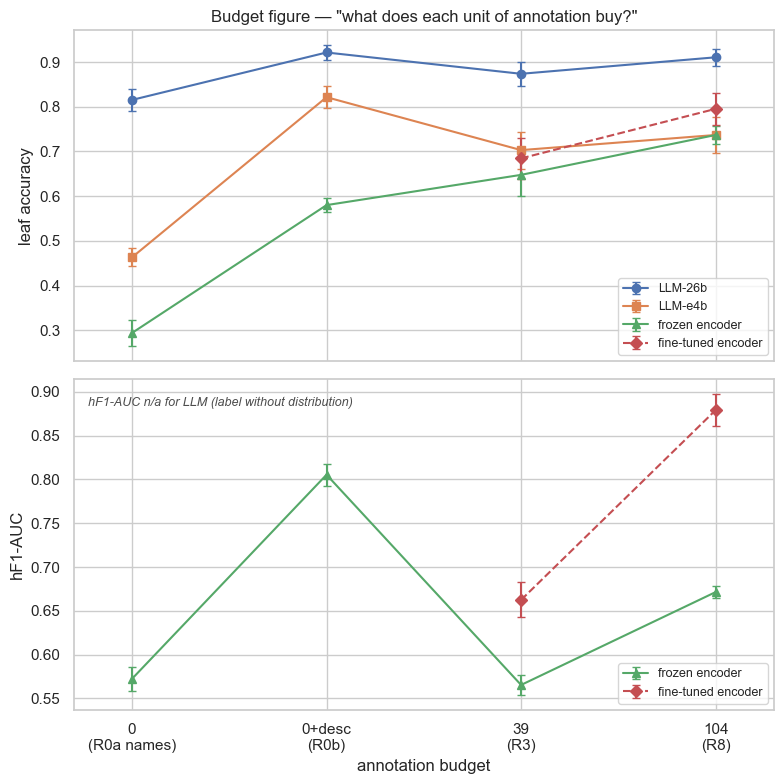

LA figure budget écrite -> artifacts/the_budget_figure.png (dpi=201, gitignoré).
4 courbes: LLM-26b, LLM-e4b, encodeur gelé, encodeur fine-tuné (partielle x∈{39,104}).


In [17]:
# ANA-06 — LA figure budget. Tout est tiré de `unified` ; rien n'est codé en dur.
# Positions x catégorielles (0 et 0+desc non séparables numériquement) :
X_POS = {"R0a": 0, "R0b": 1, "R3": 2, "R8": 3}
X_TICKLABELS = ["0\n(R0a names)", "0+desc\n(R0b)", "39\n(R3)", "104\n(R8)"]

# Une courbe = liste ordonnée de (régime, système unified) ; le tracé lit `unified`.
CURVES = {
    "LLM-26b":            [("R0a","llm_gemma4:26b_0a"),("R0b","llm_gemma4:26b_0b"),
                           ("R3","llm_gemma4:26b_3"),("R8","llm_gemma4:26b_8")],
    "LLM-e4b":            [("R0a","llm_gemma4:e4b_0a"),("R0b","llm_gemma4:e4b_0b"),
                           ("R3","llm_gemma4:e4b_3"),("R8","llm_gemma4:e4b_8")],
    "frozen encoder":     [("R0a","sim_names"),("R0b","sim_desc"),
                           ("R3","linear_probe_3"),("R8","linear_probe_8")],
    "fine-tuned encoder": [("R3","setfit_3"),("R8","setfit_8")],   # PARTIAL — x in {39,104} only
}
CURVE_STYLE = {
    "LLM-26b":            dict(color="C0", marker="o"),
    "LLM-e4b":            dict(color="C1", marker="s"),
    "frozen encoder":     dict(color="C2", marker="^"),
    "fine-tuned encoder": dict(color="C3", marker="D", linestyle="--"),
}

def _mean_std(model, metric):
    """(mean, std) sur les seeds depuis `unified` ; (nan,nan) si la métrique est absente (LLM hf1_auc)."""
    s = unified[(unified["model"] == model) & (unified["metric"] == metric)]["value"]
    if len(s) == 0:
        return np.nan, np.nan
    return float(s.mean()), float(s.std())

fig, (ax_acc, ax_auc) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# --- panneau du haut : leaf accuracy (toutes les 4 courbes) ---
for label, pts in CURVES.items():
    xs, ys, es = [], [], []
    for regime, model in pts:
        m, sd = _mean_std(model, "leaf_accuracy")
        xs.append(X_POS[regime]); ys.append(m); es.append(0.0 if np.isnan(sd) else sd)
    ax_acc.errorbar(xs, ys, yerr=es, capsize=3, label=label, **CURVE_STYLE[label])
ax_acc.set_ylabel("leaf accuracy")
ax_acc.set_title("Budget figure — \"what does each unit of annotation buy?\"")
ax_acc.legend(loc="lower right", fontsize=9)

# --- panneau du bas : hF1-AUC (LLM absent par construction -> seulement les courbes encodeur) ---
for label, pts in CURVES.items():
    xs, ys, es = [], [], []
    for regime, model in pts:
        m, sd = _mean_std(model, "hf1_auc")
        if np.isnan(m):          # absence structurée : pas de point LLM
            continue
        xs.append(X_POS[regime]); ys.append(m); es.append(0.0 if np.isnan(sd) else sd)
    if xs:                        # ne trace que les familles qui ont un hf1_auc (encodeurs)
        ax_auc.errorbar(xs, ys, yerr=es, capsize=3, label=label, **CURVE_STYLE[label])
ax_auc.set_ylabel("hF1-AUC")
ax_auc.set_xlabel("annotation budget")
ax_auc.annotate("hF1-AUC n/a for LLM (label without distribution)",
                xy=(0.02, 0.92), xycoords="axes fraction", fontsize=9,
                style="italic", color="0.3")
ax_auc.legend(loc="lower right", fontsize=9)

# x-ticks catégoriels partagés
ax_auc.set_xticks(list(X_POS.values()))
ax_auc.set_xticklabels(X_TICKLABELS)
for ax in (ax_acc, ax_auc):
    ax.set_xlim(-0.3, 3.3)

fig.tight_layout()
# PNG dans artifacts/ gitignoré (>=200 dpi) — NE PAS git-add (Pitfall 6).
# Le PNG stocke la résolution en points/mètre (chunk pHYs, entier) : 200 dpi -> 7874 dpm
# se relit 199.9996 dpi (perte d'arrondi dpi<->dpm, 200 dpi n'est pas représentable exactement).
# On grave donc à 201 dpi pour que la métadonnée embarquée franchisse sans ambiguïté le seuil >=200 dpi.
fig.savefig("artifacts/the_budget_figure.png", dpi=201, bbox_inches="tight")
plt.show()
print("LA figure budget écrite -> artifacts/the_budget_figure.png (dpi=201, gitignoré).")
print("4 courbes: LLM-26b, LLM-e4b, encodeur gelé, encodeur fine-tuné (partielle x∈{39,104}).")


## ANA-07 — Deltas appariés étendus + slopegraphs (par régime ET par famille)

Deux axes d'appariement, chacun avec ses stats `helpers.paired_tests` (Wilcoxon exact + test des
signes, plancher n=5) et un slopegraph par seed via `helpers.plot_slopegraph` (matplotlib brut —
jamais seaborn, qui agrège et masque les lignes par-seed) :

- **par régime** (famille vs famille à budget égal) : R8 linear_probe_8 vs setfit_8, R8
  encodeur-meilleur vs LLM-meilleur, R3 linear_probe_3 vs setfit_3, R0a sim_names vs LLM, R0b
  sim_desc vs LLM — chaque « meilleur » est **dérivé de `unified`** (argmax de la moyenne
  leaf_accuracy), jamais codé en dur ;
- **par famille** (régime n vs n+1) : encodeur gelé sim_names→sim_desc→probe_3→probe_8, fine-tuné
  setfit_3→setfit_8, LLM-26b et LLM-e4b 0a→0b→3→8.

Chaque delta est `value(model_b) - value(model_a)` par seed (pivot sur `unified`). Métrique appariée :
`leaf_accuracy` (commune à tous les systèmes ; hf1_auc n'existe pas pour les LLM).

=== Axe 1 — par régime (famille vs famille à budget égal) ===


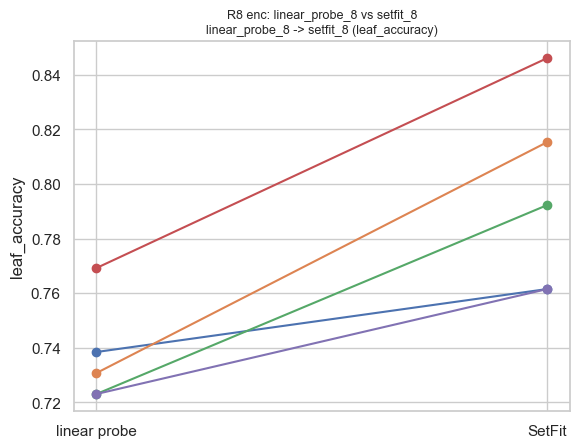

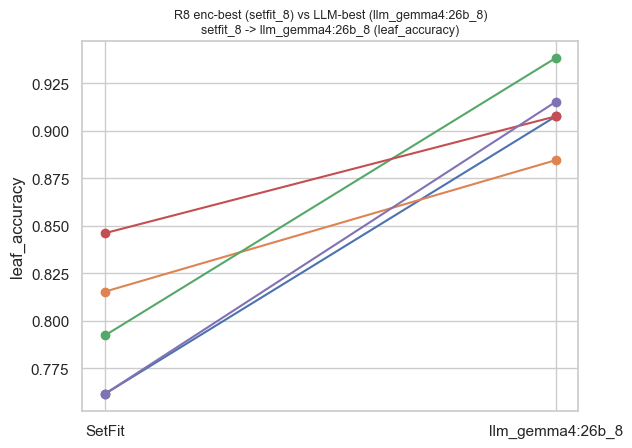

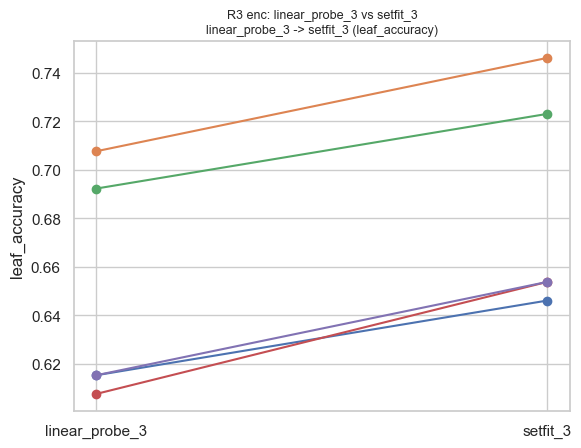

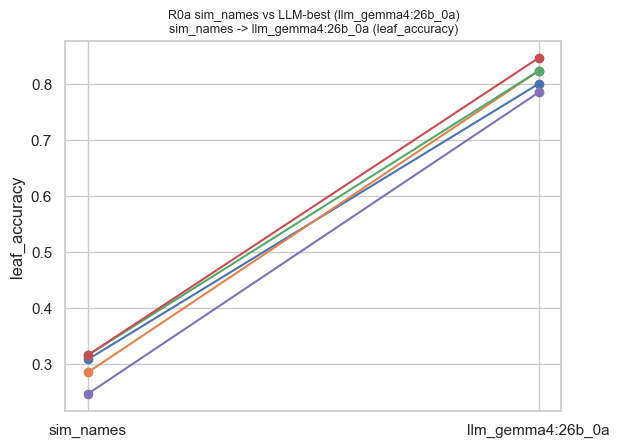

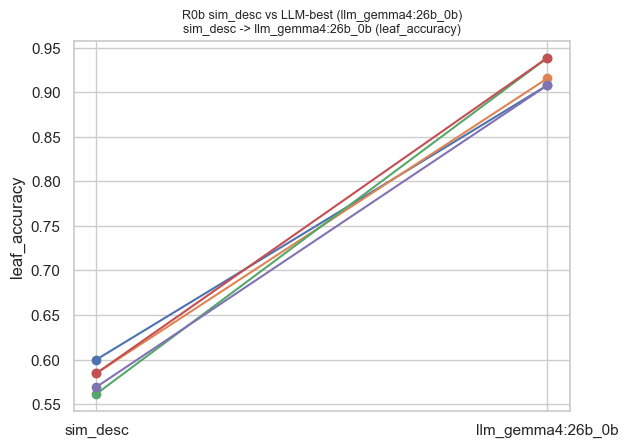


=== Axe 2 — par famille (régime n vs n+1) ===


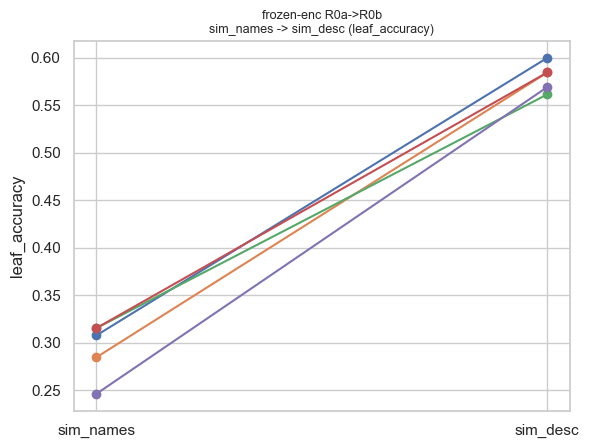

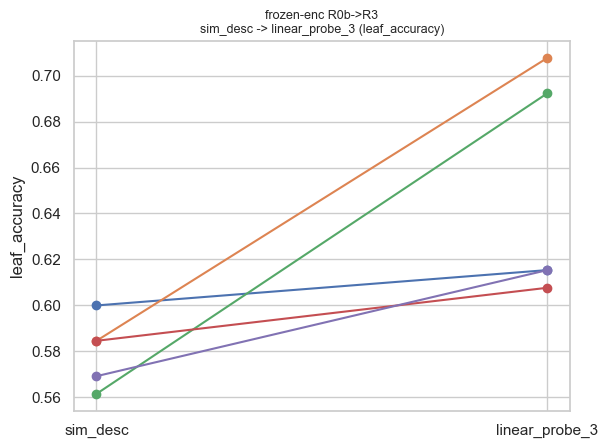

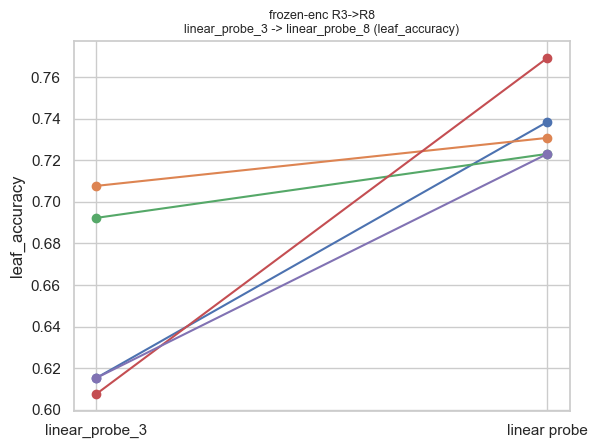

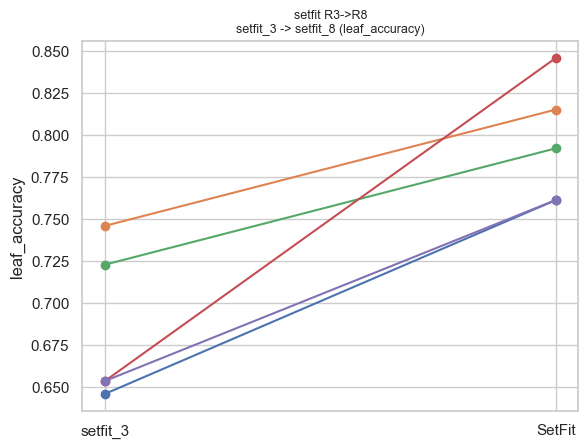

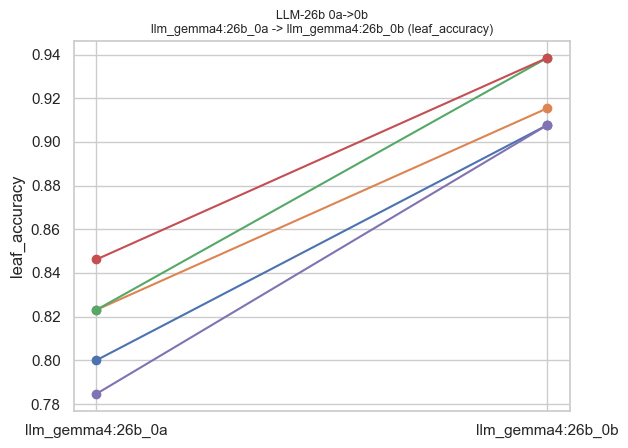

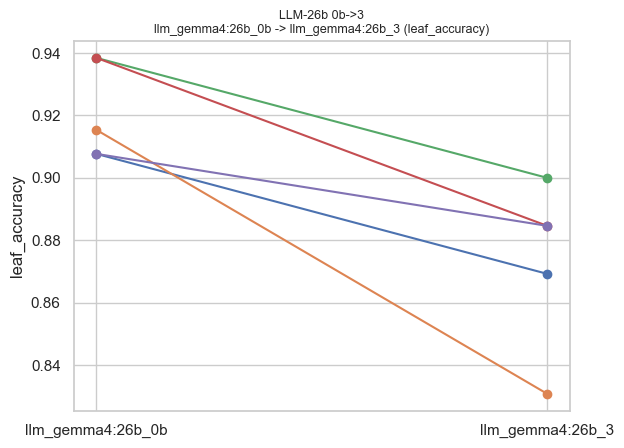

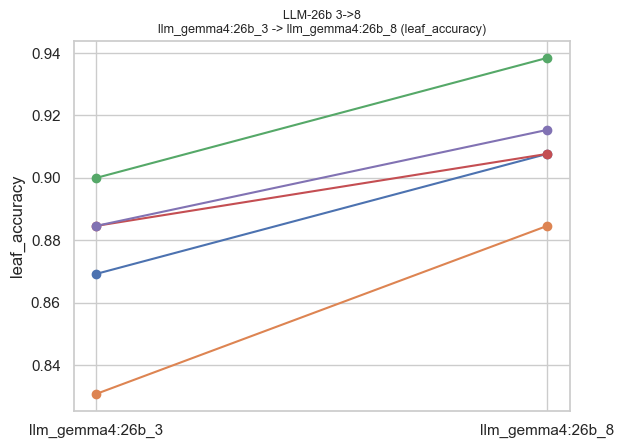

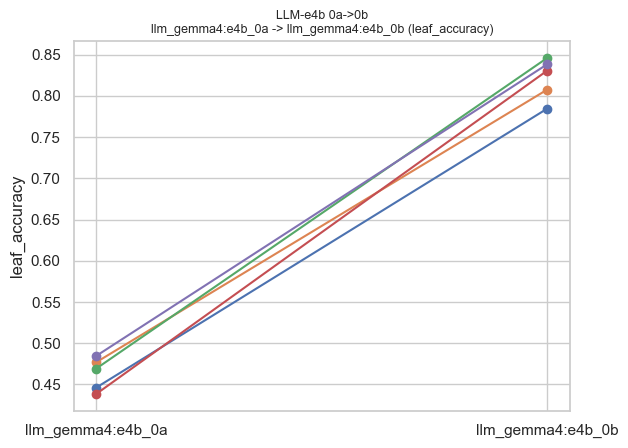

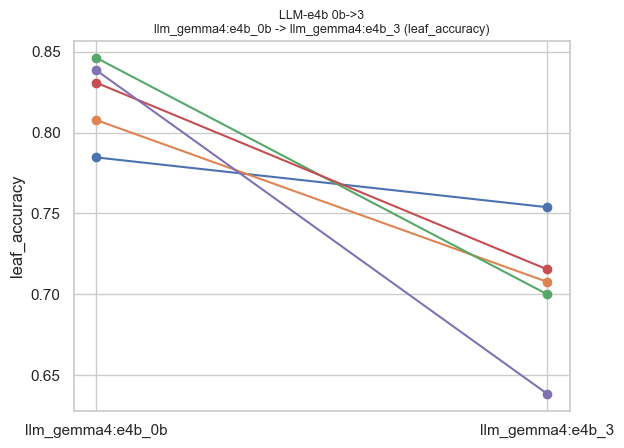

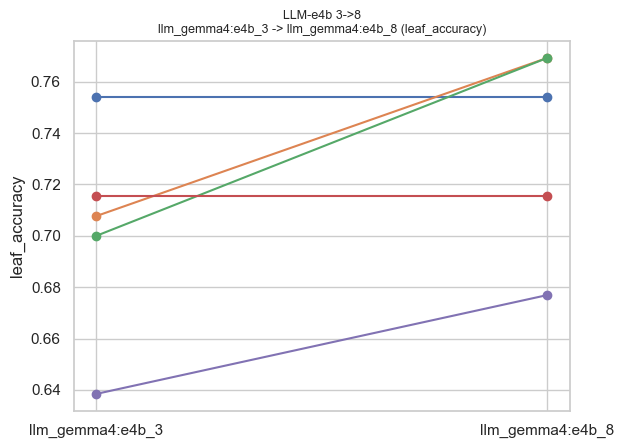


Stats appariées (leaf_accuracy) — 15 appariements (5 par-régime + 10 par-famille) :


pairing,a,b,metric,mean_delta,n_positive,n,wilcoxon_p,sign_p,min_attainable_p
R8 enc: linear_probe_8 vs setfit_8,linear_probe_8,setfit_8,leaf_accuracy,+0.058,5,5,0.0312,0.0312,0.0312
R8 enc-best (setfit_8) vs LLM-best (llm_gemma4:26b_8),setfit_8,llm_gemma4:26b_8,leaf_accuracy,+0.115,5,5,0.0312,0.0312,0.0312
R3 enc: linear_probe_3 vs setfit_3,linear_probe_3,setfit_3,leaf_accuracy,+0.037,5,5,0.0312,0.0312,0.0312
R0a sim_names vs LLM-best (llm_gemma4:26b_0a),sim_names,llm_gemma4:26b_0a,leaf_accuracy,+0.522,5,5,0.0312,0.0312,0.0312
R0b sim_desc vs LLM-best (llm_gemma4:26b_0b),sim_desc,llm_gemma4:26b_0b,leaf_accuracy,+0.342,5,5,0.0312,0.0312,0.0312
frozen-enc R0a->R0b,sim_names,sim_desc,leaf_accuracy,+0.286,5,5,0.0312,0.0312,0.0312
frozen-enc R0b->R3,sim_desc,linear_probe_3,leaf_accuracy,+0.068,5,5,0.0312,0.0312,0.0312
frozen-enc R3->R8,linear_probe_3,linear_probe_8,leaf_accuracy,+0.089,5,5,0.0312,0.0312,0.0312
setfit R3->R8,setfit_3,setfit_8,leaf_accuracy,+0.111,5,5,0.0312,0.0312,0.0312
LLM-26b 0a->0b,llm_gemma4:26b_0a,llm_gemma4:26b_0b,leaf_accuracy,+0.106,5,5,0.0312,0.0312,0.0312


In [10]:
# ANA-07 — deltas appariés + paired_tests + slopegraphs ; tout tiré de `unified`.
PAIR_METRIC = "leaf_accuracy"   # commune aux 3 paradigmes (hf1_auc absent pour LLM)

def paired_delta(model_a, model_b, metric=PAIR_METRIC):
    """Deltas par seed value(b)-value(a) via pivot sur `unified` (seeds alignés)."""
    sub = unified[(unified["metric"] == metric) & (unified["model"].isin([model_a, model_b]))]
    wide = sub.pivot_table(index="seed", columns="model", values="value")
    wide = wide.dropna()
    # STOP si l'appariement rétrécit silencieusement le design (seed manquant pour a ou b) :
    # un n < 5 fausserait mean_delta / Wilcoxon / signe sans aucun indice dans la table.
    assert len(wide) == len(h.SEEDS), \
        f"appariement {model_a} vs {model_b} ({metric}): {len(wide)} seeds != {len(h.SEEDS)} — STOP"
    return (wide[model_b] - wide[model_a]).values, wide

def report_pairing(label, model_a, model_b, metric=PAIR_METRIC):
    deltas, wide = paired_delta(model_a, model_b, metric)
    st = h.paired_tests(deltas)                      # Wilcoxon exact + signe, plancher n=5
    row = {"pairing": label, "a": model_a, "b": model_b, "metric": metric,
           "mean_delta": float(np.mean(deltas)),
           "n_positive": st["n_positive"], "n": st["n"],
           "wilcoxon_p": st["wilcoxon_p"], "sign_p": st["sign_p"],
           "min_attainable_p": st["min_attainable_p"]}
    # slopegraph par seed (matplotlib brut via helpers ; jamais seaborn)
    fig, ax = h.plot_slopegraph(unified, metric, models=(model_a, model_b))
    ax.set_title(f"{label}\n{model_a} -> {model_b} ({metric})", fontsize=9)
    plt.show()
    plt.close(fig)
    return row

# --- axe 1 : par régime (famille vs famille, budget égal) ---
# « best » est DÉRIVÉ de `unified` (argmax de la moyenne leaf_accuracy sur les seeds),
# jamais codé en dur : une grille régénérée ne peut pas rendre l'étiquette fausse.
def _best_of(models, metric=PAIR_METRIC):
    means = {m: unified[(unified["model"] == m) & (unified["metric"] == metric)]["value"].mean()
             for m in models}
    assert all(np.isfinite(v) for v in means.values()), f"moyenne absente: {means} — STOP"
    return max(means, key=means.get)

LLM_BEST = {c: _best_of([f"llm_{m}_{c}" for m in LLM_MODELS]) for c in LLM_CONDS}
ENC_BEST_R8 = _best_of(["linear_probe_8", "setfit_8"])

PER_REGIME = [
    ("R8 enc: linear_probe_8 vs setfit_8", "linear_probe_8", "setfit_8"),
    (f"R8 enc-best ({ENC_BEST_R8}) vs LLM-best ({LLM_BEST['8']})", ENC_BEST_R8, LLM_BEST["8"]),
    ("R3 enc: linear_probe_3 vs setfit_3", "linear_probe_3",  "setfit_3"),
    (f"R0a sim_names vs LLM-best ({LLM_BEST['0a']})", "sim_names", LLM_BEST["0a"]),
    (f"R0b sim_desc vs LLM-best ({LLM_BEST['0b']})", "sim_desc", LLM_BEST["0b"]),
]
# --- axe 2 : par famille (régime n vs n+1) ---
PER_FAMILY = [
    ("frozen-enc R0a->R0b", "sim_names", "sim_desc"),
    ("frozen-enc R0b->R3",  "sim_desc",  "linear_probe_3"),
    ("frozen-enc R3->R8",   "linear_probe_3", "linear_probe_8"),
    ("setfit R3->R8",       "setfit_3",  "setfit_8"),
    ("LLM-26b 0a->0b",      "llm_gemma4:26b_0a", "llm_gemma4:26b_0b"),
    ("LLM-26b 0b->3",       "llm_gemma4:26b_0b", "llm_gemma4:26b_3"),
    ("LLM-26b 3->8",        "llm_gemma4:26b_3",  "llm_gemma4:26b_8"),
    ("LLM-e4b 0a->0b",      "llm_gemma4:e4b_0a", "llm_gemma4:e4b_0b"),
    ("LLM-e4b 0b->3",       "llm_gemma4:e4b_0b", "llm_gemma4:e4b_3"),
    ("LLM-e4b 3->8",        "llm_gemma4:e4b_3",  "llm_gemma4:e4b_8"),
]

print("=== Axe 1 — par régime (famille vs famille à budget égal) ===")
regime_rows = [report_pairing(*p) for p in PER_REGIME]
print("\n=== Axe 2 — par famille (régime n vs n+1) ===")
family_rows = [report_pairing(*p) for p in PER_FAMILY]

paired_stats = pd.DataFrame(regime_rows + family_rows)
fmt = {"mean_delta": "{:+.3f}", "wilcoxon_p": "{:.4f}",
       "sign_p": "{:.4f}", "min_attainable_p": "{:.4f}"}
print(f"\nStats appariées ({PAIR_METRIC}) — {len(paired_stats)} appariements "
      f"({len(regime_rows)} par-régime + {len(family_rows)} par-famille) :")
display(paired_stats.style.format(fmt).hide(axis="index"))


## ANA-08 — Rapport d'audit (taux de global_fallback + sensibilité à T)

Le rapport d'audit calcule le taux de `global_fallback` par (model, condition) à partir du CSV LLM
(variable `global_fallback` héritée de la porte ANA-02) et **signale toute condition > 2 %**. Le
seuil est calculé sur la donnée : aucun « 0 % » codé en dur ne se substitue à la valeur recalculée
(Pitfall 7) — sur la donnée courante le taux est 0 % partout, donc le rapport l'ÉNONCE depuis la
valeur calculée. Sur la sensibilité à T (correctif WR-03) : seules les prédictions **argmax** (donc
accuracy et F1) sont T-invariantes ; l'hF1-AUC zero-shot encodeur (budget 0) **et**
l'ordre de confiance **inter-exemples** (max softmax, celui qui trie le triage ANA-09
des systèmes sim_*) dépendent tous deux du T=0,05 fixé — pour ≥3 classes le max
softmax n'est pas monotone en T entre exemples. Les deux dépendances sont
**quantifiées par le balayage ANA-10**. La description de la passe LLM lit `num_ctx_by_condition` (R8=32768).

In [11]:
# ANA-08 — rapport d'audit. global_fallback calculé (jamais "0%" codé en dur), flag >2%, ligne T, num_ctx.
FALLBACK_GATE = 0.02

audit = (global_fallback.rename("fallback_rate").reset_index())   # par (model,condition), depuis ANA-02
audit["flag_>2%"] = audit["fallback_rate"] > FALLBACK_GATE
n_flagged = int(audit["flag_>2%"].sum())
max_rate = float(audit["fallback_rate"].max())

print("Audit global_fallback — taux par (model, condition) :")
display(audit.style.format({"fallback_rate": "{:.4f}"}).hide(axis="index"))

# Énoncé DÉRIVÉ de la valeur calculée (Pitfall 7 — pas de littéral "0%").
if n_flagged == 0:
    print(f"global_fallback : {max_rate:.2%} max sur toutes les conditions "
          f"(seuil {FALLBACK_GATE:.0%} non franchi) — porte non déclenchée.")
else:
    flagged = audit[audit["flag_>2%"]][["model","condition","fallback_rate"]]
    print(f"global_fallback : {n_flagged} condition(s) > {FALLBACK_GATE:.0%} — À SIGNALER :")
    display(flagged)

# Sensibilité à T (prose, ENC-03) : l'hF1-AUC zero-shot encodeur dépend du T fixé.
T_FIXED = 0.05
sim_auc = (unified[(unified["model"].isin(["sim_names","sim_desc"])) & (unified["metric"]=="hf1_auc")]
           .groupby("model")["value"].mean())
print(f"\nSensibilité à T : l'hF1-AUC zero-shot encodeur (budget 0) est calculé à T={T_FIXED} fixé "
      f"(sim_names={sim_auc.get('sim_names', float('nan')):.3f}, "
      f"sim_desc={sim_auc.get('sim_desc', float('nan')):.3f}). "
      f"Les prédictions argmax (accuracy / leaf-F1 / hier-F1) sont T-invariantes ; "
      f"en revanche la forme de la distribution softmax(cos/T) — donc l'hF1-AUC — ET "
      f"l'ordre de confiance inter-exemples (max softmax) qui trie le triage ANA-09 "
      f"dépendent tous deux de T (non monotone entre exemples pour >=3 classes ; "
      f"correctif WR-03). Les deux dépendances sont quantifiées par le balayage ANA-10.")

# Description de la passe LLM (num_ctx_by_condition lu du sidecar, R8=32768).
print(f"\nPasse LLM : num_ctx par condition = {num_ctx_by_condition} "
      f"(R8 à {num_ctx_by_condition.get('8', 'n/a')}, conditions économiques à "
      f"{num_ctx_by_condition.get('0a', 'n/a')}). hF1-AUC rapporté comme capacité "
      f"DIFFÉRENTIELLE de la famille encodeur (n/a pour LLM = label sans distribution), pas un écart.")


Audit global_fallback — taux par (model, condition) :


model,condition,fallback_rate,flag_>2%
gemma4:26b,0a,0.0000,False
gemma4:26b,0b,0.0000,False
gemma4:26b,3,0.0000,False
gemma4:26b,8,0.0000,False
gemma4:e4b,0a,0.0000,False
gemma4:e4b,0b,0.0000,False
gemma4:e4b,3,0.0000,False
gemma4:e4b,8,0.0000,False


global_fallback : 0.00% max sur toutes les conditions (seuil 2% non franchi) — porte non déclenchée.

Sensibilité à T : l'hF1-AUC zero-shot encodeur (budget 0) est calculé à T=0.05 fixé (sim_names=0.572, sim_desc=0.805). Les prédictions argmax (accuracy / leaf-F1 / hier-F1) sont T-invariantes ; en revanche la forme de la distribution softmax(cos/T) — donc l'hF1-AUC — ET l'ordre de confiance inter-exemples (max softmax) qui trie le triage ANA-09 dépendent tous deux de T (non monotone entre exemples pour >=3 classes ; correctif WR-03). Les deux dépendances sont quantifiées par le balayage ANA-10.

Passe LLM : num_ctx par condition = {'0a': 16384, '0b': 16384, '3': 16384, '8': 32768} (R8 à 32768, conditions économiques à 16384). hF1-AUC rapporté comme capacité DIFFÉRENTIELLE de la famille encodeur (n/a pour LLM = label sans distribution), pas un écart.


## ANA-09 — Triage par seuil de confiance (risque vs couverture, 6 systèmes, PAR SEED)

Question de triage (cadrage v2.1, cellule `0a05305` ; correctif d'ordre de clés `03335a3`) :
**trier les prédictions par confiance décroissante ; en automatisant les `k` % les plus
confiants, quel taux d'erreur encourt-on ?** La confiance est la probabilité feuille max
(`probs.max(axis=1)`) ; la correction vient de `correct_{sys}.npz` (vecteur booléen, ordre
test-frame). Les deux sont **appariés par seed** via UNE liste de clés canonique
`[str(s) for s in h.SEEDS]` (assert d'égalité d'ensembles, correctif `03335a3` : jamais deux
boucles `.files` indépendantes).

**Correctif WR-01 (revue 2026-06-12) — par seed ; le pooling n'est plus la vue principale.**
L'ancienne cellule concaténait les 650 exemples des 5 seeds avant le tri : (1) le chiffre
opérationnel (« X % automatisable à ≤ 5 % d'erreur ») était un point estimé **sans
incertitude**, alors que n=5 seeds existent précisément pour la quantifier (résultats
few-shot bruités) ; (2) pour `setfit_3`/`setfit_8` chaque seed est un **réseau fine-tuné
distinct** avec sa propre calibration de confiance — trier des confiances inter-modèles
mélange des échelles non comparables, et la courbe poolée ne correspond à **aucune politique
de triage déployable** (un déploiement = un modèle + un seuil). La cellule calcule donc
`risk_coverage` **par seed** (5 courbes de 130 points ; les 5 test-sets ont la même taille,
donc la grille de couverture est identique par construction — asserté), trace la **courbe
moyenne ± 1 écart-type** par système, et imprime la couverture max atteignable à risque
≤ 5 % / ≤ 10 % en **mean ± std (min–max)** sur les seeds. La vue poolée est conservée
uniquement comme panneau **SUPPLÉMENTAIRE** explicitement étiqueté (descriptif v2.1).

Les pourcentages exacts par système sont **imprimés par la cellule ci-dessous** — rien n'est
codé en dur dans cette prose. La figure `artifacts/fig_risk_coverage.png` est gitignorée
(≥200 dpi) — NE PAS git-add : l'enregistrement durable dans le dépôt est la **source du
notebook**, pas le PNG — la figure se régénère en ré-exécutant le notebook sur les artefacts.


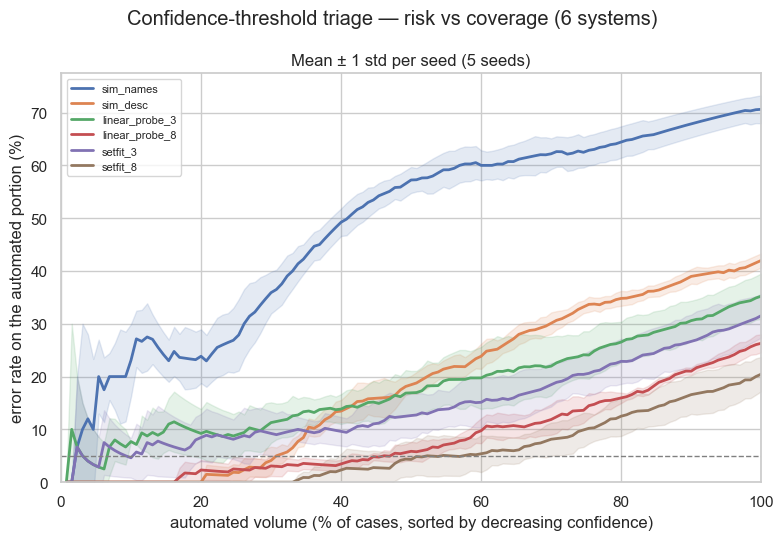

figure risque-couverture écrite -> artifacts/fig_risk_coverage.png (dpi=201, gitignoré).
      sim_names | <=5%: 4% ± 1% (min 2%, max 5%) | <=10%: 5% ± 3% (min 2%, max 9%)  [supplément poolé : <=5%: 4% <=10%: 4%]
       sim_desc | <=5%: 31% ± 3% (min 25%, max 33%) | <=10%: 37% ± 5% (min 34%, max 46%)  [supplément poolé : <=5%: 30% <=10%: 35%]
 linear_probe_3 | <=5%: 14% ± 8% (min 6%, max 25%) | <=10%: 29% ± 10% (min 14%, max 42%)  [supplément poolé : <=5%: 10% <=10%: 28%]
 linear_probe_8 | <=5%: 48% ± 5% (min 41%, max 54%) | <=10%: 63% ± 7% (min 57%, max 74%)  [supplément poolé : <=5%: 45% <=10%: 62%]
       setfit_3 | <=5%: 16% ± 17% (min 2%, max 46%) | <=10%: 44% ± 15% (min 19%, max 65%)  [supplément poolé : <=5%: 10% <=10%: 36%]
       setfit_8 | <=5%: 58% ± 14% (min 37%, max 75%) | <=10%: 72% ± 12% (min 50%, max 88%)  [supplément poolé : <=5%: 56% <=10%: 75%]


In [15]:
# ANA-09 — triage par confiance ; risque vs couverture PAR SEED (correctif WR-01).
# Confiance = probabilité feuille max ; correction depuis correct_{sys}.npz (ordre test-frame).
# Helpers LOCAUX à la cellule (PAS dans helpers.py : descriptif, usage unique, comme la v2.1).
def risk_coverage(conf, correct):
    order = np.argsort(-conf)                       # tri par confiance décroissante
    c     = correct[order]
    cov   = np.arange(1, len(c) + 1) / len(c)       # couverture = fraction automatisée
    risk  = np.cumsum(~c) / np.arange(1, len(c) + 1)  # risque = taux d'erreur cumulé
    return cov, risk

def coverage_at_risk(cov, risk, thr):
    """Couverture max atteignable à risque <= thr (0.0 si aucun volume)."""
    ok = np.where(risk <= thr)[0]
    return float(cov[ok[-1]]) if len(ok) else 0.0

curves_seed = {}     # sys -> (cov_grid (N,), risks (5, N)) — vue PRINCIPALE par seed
curves_pool = {}     # sys -> (cov, risk) poolé             — vue SUPPLÉMENTAIRE (descriptive)
keys = [str(s) for s in h.SEEDS]                     # UNE liste de clés canonique
for sys_name in ENC_SYSTEMS:                         # six systèmes (portée LOCKED, pas deux)
    C = np.load(f"artifacts/correct_{sys_name}.npz")
    assert set(keys) == set(C.files), \
        f"{sys_name}: clés correct {set(C.files)} != {set(keys)}"   # correctif 03335a3
    # MEME liste de clés pour probs ET correct -> pairing par seed inaltérable.
    per_seed = [risk_coverage(enc_probs[sys_name][int(k)].max(axis=1), C[k]) for k in keys]
    n0 = len(per_seed[0][0])
    assert all(len(cov) == n0 for cov, _ in per_seed), \
        f"{sys_name}: tailles de test inégales entre seeds — grille commune impossible"
    curves_seed[sys_name] = (per_seed[0][0], np.vstack([r for _, r in per_seed]))
    # Vue poolée (v2.1) conservée en SUPPLÉMENT seulement : pour setfit_3/8 chaque seed est
    # un réseau distinct (calibrations non comparables) — le pooling n'équivaut à aucune
    # politique de triage déployable (WR-01).
    conf = np.concatenate([enc_probs[sys_name][int(k)].max(axis=1) for k in keys])
    corr = np.concatenate([C[k] for k in keys])
    curves_pool[sys_name] = risk_coverage(conf, corr)

TARGET = 0.05                                        # taux d'erreur toléré (ligne de référence)

fig, ax = plt.subplots(1, 1, figsize=(8, 5.5))
for sys_name in ENC_SYSTEMS:
    cov, risks = curves_seed[sys_name]
    mean_r, std_r = risks.mean(axis=0), risks.std(axis=0)
    line, = ax.plot(cov * 100, mean_r * 100, lw=2.0, label=sys_name)
    ax.fill_between(cov * 100, (mean_r - std_r) * 100, (mean_r + std_r) * 100,
                    color=line.get_color(), alpha=0.15)
ax.set_title("Mean ± 1 std per seed (5 seeds)")
ax.axhline(TARGET * 100, ls="--", c="gray", lw=1)    # seuil d'erreur toléré
ax.set_xlabel("automated volume (% of cases, sorted by decreasing confidence)")
ax.set_xlim(0, 100); ax.set_ylim(0, None)
ax.legend(loc="upper left", fontsize=8)
ax.set_ylabel("error rate on the automated portion (%)")
fig.suptitle("Confidence-threshold triage — risk vs coverage (6 systems)")
fig.tight_layout()
# PNG dans artifacts/ gitignoré (>=200 dpi) — NE PAS git-add (Pitfall 6).
# Le PNG stocke la résolution en points/mètre (chunk pHYs, entier) : 200 dpi -> 7874 dpm
# se relit 199.9996 dpi (perte d'arrondi dpi<->dpm, 200 dpi n'est pas représentable exactement).
# On grave donc à 201 dpi pour que la métadonnée embarquée franchisse sans ambiguïté le seuil >=200 dpi.
fig.savefig("artifacts/fig_risk_coverage.png", dpi=201, bbox_inches="tight")  # dpi=201, JAMAIS 200
plt.show()
print("figure risque-couverture écrite -> artifacts/fig_risk_coverage.png (dpi=201, gitignoré).")

# Volume automatisable à <=5% / <=10% d'erreur — PAR SEED, rapporté mean ± std (min–max)
# sur n=5 seeds (WR-01) ; calculé LIVE, jamais codé en dur. La valeur poolée n'est plus
# imprimée qu'en SUPPLÉMENT, explicitement étiquetée.
for sys_name in ENC_SYSTEMS:
    cov, risks = curves_seed[sys_name]
    parts = []
    for thr in (0.05, 0.10):
        per = np.array([coverage_at_risk(cov, r, thr) for r in risks])
        parts.append(f"<={thr:.0%}: {per.mean():.0%} ± {per.std():.0%} "
                     f"(min {per.min():.0%}, max {per.max():.0%})")
    pcov, prisk = curves_pool[sys_name]
    pooled = " ".join(f"<={thr:.0%}: {coverage_at_risk(pcov, prisk, thr):.0%}"
                      for thr in (0.05, 0.10))
    print(f"{sys_name:>15} | " + " | ".join(parts) + f"  [supplément poolé : {pooled}]")


## ANA-10 — Sensibilité à T : balayage `T ∈ {0.01, 0.025, 0.05, 0.1}` (zéro-shot, WR-02)

Correctif WR-02 (revue 2026-06-12). L'hF1-AUC zéro-shot (`sim_names` R0a / `sim_desc` R0b)
est calculé sur les marginales `softmax(cos/T)` : T ne change pas l'argmax (accuracy / F1
invariants), mais **reforme la distribution** et donc l'hF1-AUC balayé par seuils — la
métrique-titre du papier — ainsi que (WR-03) **l'ordre de confiance inter-exemples**
(max softmax) qui trie les courbes risque-couverture d'ANA-09. Jusqu'ici `T=0.05` était
figé (ENC-03) sans preuve de robustesse : cette cellule la fournit. Le balayage est
**pur numpy sur artefacts en cache** (`st_emb_all.npy` + 13 embeddings d'étiquettes) :
aucun ré-entraînement. Pour chaque T et chaque seed, on recompute
`zero_shot_similarity -> flat_leaf_probs_to_marginals -> hf1_auc`, plus la couverture
de triage max à risque ≤ 5 % (réutilise `risk_coverage`/`coverage_at_risk` d'ANA-09).
Une porte de reproduction vérifie qu'à `T=0.05` le balayage REPRODUIT exactement les
valeurs de `unified` (ANA-04). La phrase de stabilité du classement R0 vs systèmes
supervisés est **dérivée des valeurs calculées** (Pitfall 7), jamais codée en dur.
**Aucun chiffre-titre de la grille ne change** : T=0.05 reste la valeur rapportée.


In [14]:
# ANA-10 — balayage de T (WR-02) + dépendance à T du triage sim_* (WR-03).
# Tout est recomputé depuis les caches : st_emb_all.npy (textes) + encodage des 13
# étiquettes (D-01 noms dé-sluggés / D-02 descriptions) — pur numpy, pas d'entraînement.
# Dépend d'ANA-09 (risk_coverage, coverage_at_risk) et d'ANA-04 (unified, LEAF_ORDER, tax).
df_T = df.copy()
df_T["_id"] = np.arange(len(df_T))                  # même convention _id que 01_flat
splits_T = h.make_balanced_splits(df_T, seeds=h.SEEDS)
emb_all = h.cached_st_embeddings(df_T.text.tolist(), cache_path="artifacts/st_emb_all.npy",
                                 name=h.ENCODER_NAME, device=DEVICE)   # hit cache (PIPE-01)

# Embeddings des 13 étiquettes, alignés sur LEAF_ORDER — MEME construction que 01_flat.
st_enc = h.st_model(h.ENCODER_NAME, DEVICE)
names_text = [lf.replace("-", " ").replace("/", " ") for lf in LEAF_ORDER]   # D-01
_desc = json.load(open("data/leaf_descriptions.json"))["leaves"]
desc_text = [names_text[i] + " " + _desc[lf]["general"] + " " + " ".join(_desc[lf].get("indicators", []))
             for i, lf in enumerate(LEAF_ORDER)]                                            # D-02
LABEL_EMB = {"sim_names": h.st_encode(st_enc, names_text),
             "sim_desc":  h.st_encode(st_enc, desc_text)}

def zero_shot_similarity(texts_emb, label_emb, temperature=0.05):
    """Copie VERBATIM du contrat de 01_flat : softmax(cos/T), ligne-stochastique."""
    sims = np.asarray(texts_emb) @ np.asarray(label_emb).T   # (N, L) cosinus (L2-normés)
    z = sims / temperature
    z = z - z.max(axis=1, keepdims=True)                     # softmax stable
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

T_SWEEP = (0.01, 0.025, 0.05, 0.1)
rows_T = []
for T in T_SWEEP:
    for sys_name, L in LABEL_EMB.items():
        for seed in h.SEEDS:
            te = splits_T[seed]["test"]
            Xte = emb_all[te._id.values]
            prob = zero_shot_similarity(Xte, L, temperature=T)
            auc = h.hf1_auc(h.flat_leaf_probs_to_marginals(prob, LEAF_ORDER, tax),
                            te.leaf_label.tolist(), tax)
            # WR-03 : la correction (argmax) est T-invariante, mais l'ORDRE de confiance
            # inter-exemples ne l'est pas -> la couverture de triage dépend de T.
            correct = np.array([LEAF_ORDER[i] for i in prob.argmax(1)]) == te.leaf_label.values
            cov, risk = risk_coverage(prob.max(axis=1), correct)
            rows_T.append({"T": T, "model": sys_name, "seed": seed, "hf1_auc": float(auc),
                           "cov_at_5pct": coverage_at_risk(cov, risk, 0.05)})
sweep = pd.DataFrame(rows_T)

# Porte de reproduction : à T=0.05 le balayage doit REPRODUIRE unified (ANA-04) à 1e-9.
_chk = sweep[np.isclose(sweep["T"], 0.05)].set_index(["model", "seed"])["hf1_auc"]
_ref = unified[(unified["metric"] == "hf1_auc") & unified["model"].isin(LABEL_EMB)]
for _, r in _ref.iterrows():
    assert abs(_chk.loc[(r["model"], r["seed"])] - r["value"]) < 1e-9, \
        f"ANA-10 STOP — T=0.05 ne reproduit pas unified pour {r['model']} seed {r['seed']}"
print("porte de reproduction OK : T=0.05 == unified (hf1_auc, 10/10 valeurs)")

# Table (T x système) mean ± std sur les 5 seeds — hF1-AUC puis couverture <=5% (WR-03).
for col, title in [("hf1_auc", "hF1-AUC"), ("cov_at_5pct", "couverture max à risque <=5%")]:
    tbl = (sweep.groupby(["T", "model"])[col].agg(["mean", "std"])
                .unstack("model").round(3))
    print(f"\n{title} — balayage de T (mean ± std, 5 seeds) :")
    display(tbl)

# Stabilité du classement R0 vs supervisé — DÉRIVÉE des valeurs (Pitfall 7) : l'ordre
# des 6 systèmes par hF1-AUC moyen (4 supervisés figés + 2 zéro-shot recalculés par T)
# est-il identique, pour chaque T du balayage, au classement rapporté à T=0.05 ?
_sup = (unified[(unified["metric"] == "hf1_auc")
                & unified["model"].isin(["linear_probe_3", "linear_probe_8",
                                          "setfit_3", "setfit_8"])]
        .groupby("model")["value"].mean().to_dict())

def _ranking(T):
    vals = dict(_sup)
    for m in LABEL_EMB:
        vals[m] = float(sweep[np.isclose(sweep["T"], T)
                              & (sweep["model"] == m)]["hf1_auc"].mean())
    return tuple(sorted(vals, key=vals.get, reverse=True))

_ref_rank = _ranking(0.05)
_unstable = [T for T in T_SWEEP if _ranking(T) != _ref_rank]
if not _unstable:
    print(f"\nClassement T-stable : pour CHAQUE T du balayage, l'ordre des 6 systèmes "
          f"par hF1-AUC moyen est identique au classement rapporté à T=0.05 "
          f"({' > '.join(_ref_rank)}) — la position des systèmes R0 face aux "
          f"supervisés ne dépend pas du choix de T.")
else:
    print(f"\nATTENTION — classement non T-stable : l'ordre des 6 systèmes diffère du "
          f"classement de T=0.05 pour T ∈ {_unstable} "
          f"(référence : {' > '.join(_ref_rank)}) — la position des systèmes R0 face "
          f"aux supervisés dépend de T.")

# WR-03 (triage) : amplitude de la dépendance à T de la couverture <=5% pour sim_*.
_cv = sweep.groupby(["model", "T"])["cov_at_5pct"].mean()
for m in LABEL_EMB:
    print(f"triage {m} : couverture <=5% varie de {_cv[m].min():.0%} à {_cv[m].max():.0%} "
          f"selon T — l'ordre de confiance inter-exemples N'EST PAS T-invariant (WR-03).")


/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


porte de reproduction OK : T=0.05 == unified (hf1_auc, 10/10 valeurs)

hF1-AUC — balayage de T (mean ± std, 5 seeds) :


mean                std          
model sim_desc sim_names sim_desc sim_names
T                                          
0.010    0.812     0.578    0.014     0.021
0.025    0.808     0.581    0.013     0.019
0.050    0.805     0.572    0.012     0.014
0.100    0.731     0.531    0.014     0.016


couverture max à risque <=5% — balayage de T (mean ± std, 5 seeds) :


mean                std          
model sim_desc sim_names sim_desc sim_names
T                                          
0.010    0.238     0.012    0.032     0.007
0.025    0.266     0.042    0.019     0.016
0.050    0.309     0.037    0.032     0.014
0.100    0.312     0.032    0.027     0.013


ATTENTION — classement non T-stable : l'ordre des 6 systèmes diffère du classement de T=0.05 pour T ∈ [0.1] (référence : setfit_8 > sim_desc > linear_probe_8 > setfit_3 > sim_names > linear_probe_3) — la position des systèmes R0 face aux supervisés dépend de T.
triage sim_names : couverture <=5% varie de 1% à 4% selon T — l'ordre de confiance inter-exemples N'EST PAS T-invariant (WR-03).
triage sim_desc : couverture <=5% varie de 24% à 31% selon T — l'ordre de confiance inter-exemples N'EST PAS T-invariant (WR-03).


## Confusion panel — 4 systems along the knowledge-gain axis

Quatre matrices (sur six) dans l'ordre du **gain de connaissance** : `sim_names` (la base qui s'effondre) → `sim_desc` (les descriptions réparent) → `linear_probe_8` & `setfit_8` (le mieux ; erreurs = sœurs). **Seed 0** (n=130). Les axes suivent `LEAF_ORDER` (chemins complets triés → sœurs adjacentes) ; les lignes grises marquent les frontières de famille niveau-1, donc la masse hors-diagonale **à l'intérieur** d'un bloc = confusion entre sœurs.

[fig] ecrite -> artifacts/images_rapport/encoder_confusion_panel_seed0.png


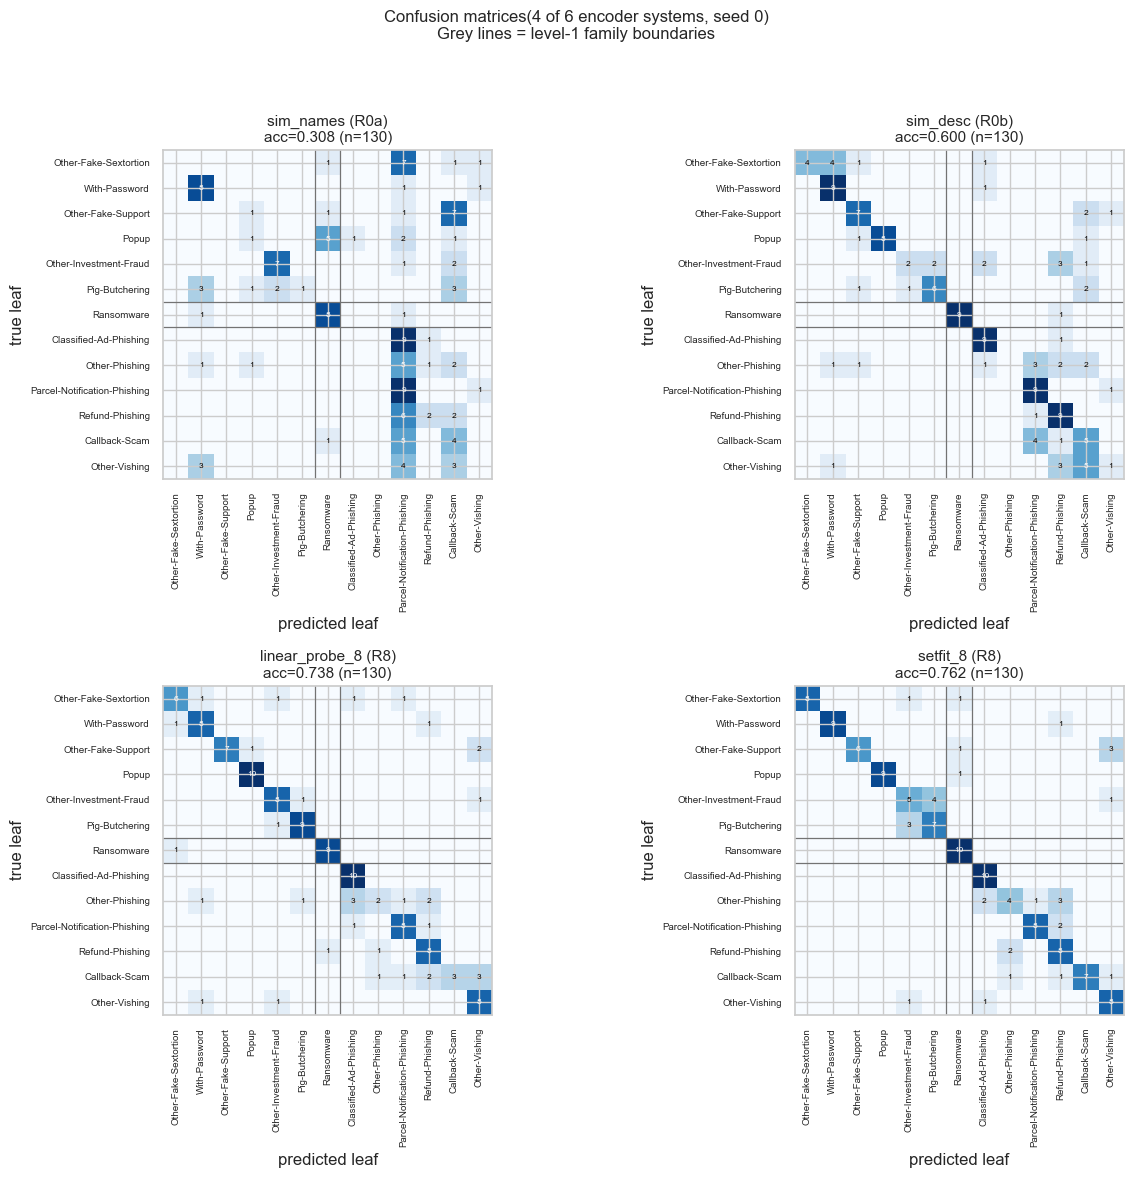

In [22]:
# Panneau de 4 matrices de confusion (encodeurs), ordre du GAIN DE CONNAISSANCE :
# sim_names (base qui s'effondre) -> sim_desc (descriptions reparent) ->
# linear_probe_8 & setfit_8 (le mieux ; erreurs = soeurs). Poole sur les 5 seeds.
# Source : enc_probs (ANA-04) + vrais labels par seed (MEME make_balanced_splits).
import os
from sklearn.metrics import confusion_matrix as _cm

PANEL = [
    ("sim_names",      "sim_names (R0a)"),
    ("sim_desc",       "sim_desc (R0b)"),
    ("linear_probe_8", "linear_probe_8 (R8)"),
    ("setfit_8",       "setfit_8 (R8)"),
]
# LEAF_ORDER = chemins complets tries -> les soeurs sont deja adjacentes.
_short  = [lf.split("/")[-1] for lf in LEAF_ORDER]
_lvl1   = [lf.split("/")[0]  for lf in LEAF_ORDER]
_bounds = [k for k in range(1, len(LEAF_ORDER)) if _lvl1[k] != _lvl1[k - 1]]   # frontieres de famille
_true_by_seed = {0: h.make_balanced_splits(df, seeds=[0])[0]["test"]
                    .reset_index(drop=True)["leaf_label"].values}

fig, axes = plt.subplots(2, 2, figsize=(13, 12))
for ax, (sys_name, title) in zip(axes.ravel(), PANEL):
    P = enc_probs[sys_name][0]                          # seed 0 uniquement (n=130)
    y_pred = [LEAF_ORDER[i] for i in P.argmax(1)]
    y_true = _true_by_seed[0]
    cm = _cm(y_true, y_pred, labels=LEAF_ORDER)
    acc = np.trace(cm) / cm.sum()
    ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{title}\nacc={acc:.3f} (n={cm.sum()})", fontsize=11)
    ax.set_xticks(range(len(LEAF_ORDER))); ax.set_yticks(range(len(LEAF_ORDER)))
    ax.set_xticklabels(_short, rotation=90, fontsize=7)
    ax.set_yticklabels(_short, fontsize=7)
    ax.set_xlabel("predicted leaf"); ax.set_ylabel("true leaf")
    for b in _bounds:                                       # frontieres lvl1 = la fratrie
        ax.axhline(b - 0.5, color="0.45", lw=0.9); ax.axvline(b - 0.5, color="0.45", lw=0.9)
    _thr = cm.max() / 2 if cm.max() else 0
    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            v = int(cm[r, c])
            if v:
                ax.text(c, r, v, ha="center", va="center", fontsize=6,
                        color="white" if v > _thr else "black")

fig.suptitle("Confusion matrices"
             "(4 of 6 encoder systems, seed 0)\n"
             "Grey lines = level-1 family boundaries",
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
_PATH = "artifacts/images_rapport/encoder_confusion_panel_seed0.png"
os.makedirs(os.path.dirname(_PATH), exist_ok=True)
fig.savefig(_PATH, dpi=300, bbox_inches="tight")
print("[fig] ecrite ->", _PATH)
plt.show()